# model training — MLP vs GCN vs GAT

In [1]:
%pip install rdkit


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import matplotlib.pyplot as plt

from dataset.dataset_util import load_esol, split_dataset, make_loaders, get_fingerprints, rmse, mae, r_squared
from gnns.gnn_util import GCNModel, GATModel, run_training, get_predictions
from nn.nn_util import MLPModel, run_training_mlp, get_predictions_mlp

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## data

In [3]:
dataset = load_esol(root='data/')
train_set, val_set, test_set = split_dataset(dataset, seed=42)

# graph loaders for GCN/GAT
train_loader, val_loader, test_loader = make_loaders(train_set, val_set, test_set, batch_size=64)

# fingerprints for MLP
X_train, y_train = get_fingerprints(train_set)
X_val, y_val = get_fingerprints(val_set)
X_test, y_test = get_fingerprints(test_set)

print(f'train: {len(train_set)}  val: {len(val_set)}  test: {len(test_set)}')

train: 902  val: 112  test: 114


## train MLP

In [4]:
mlp = MLPModel(in_features=1024, hidden=128)
print('training MLP...')
mlp_history = run_training_mlp(mlp, X_train, y_train, X_val, y_val, epochs=200, lr=0.001)

training MLP...
  epoch   1  train 10.0539  val 12.2319
  epoch  20  train 0.2829  val 1.1013
  epoch  40  train 0.2016  val 1.2394
  epoch  60  train 0.1985  val 1.1297
  epoch  80  train 0.2119  val 1.1237
  epoch 100  train 0.1617  val 1.0977
  epoch 120  train 0.1725  val 1.1570
  epoch 140  train 0.2434  val 1.2143
  epoch 160  train 0.1938  val 1.1879
  epoch 180  train 0.1523  val 1.2552
  epoch 200  train 0.1820  val 1.2754


## train GCN

In [5]:
gcn = GCNModel(in_channels=dataset.num_node_features, hidden=128)
print('training GCN...')
gcn_history = run_training(gcn, train_loader, val_loader, epochs=200, lr=0.001)

training GCN...
  epoch   1  train 10.4177  val 10.0987
  epoch  20  train 1.0610  val 1.1967
  epoch  40  train 0.9322  val 1.2424
  epoch  60  train 0.8245  val 1.1179
  epoch  80  train 0.9062  val 1.2100
  epoch 100  train 0.7170  val 0.9096
  epoch 120  train 0.7353  val 1.0769
  epoch 140  train 0.6887  val 0.8458
  epoch 160  train 0.6973  val 1.1374
  epoch 180  train 0.6551  val 1.5224
  epoch 200  train 0.6339  val 0.9952


## train GAT

In [6]:
gat = GATModel(in_channels=dataset.num_node_features, hidden=128, heads=4)
print('training GAT...')
gat_history = run_training(gat, train_loader, val_loader, epochs=200, lr=0.001)

training GAT...
  epoch   1  train 10.8988  val 10.4892
  epoch  20  train 0.8490  val 1.1841
  epoch  40  train 0.7152  val 1.0083
  epoch  60  train 0.7142  val 1.0510
  epoch  80  train 0.5910  val 0.9404
  epoch 100  train 0.5705  val 0.8560
  epoch 120  train 0.5113  val 0.8267
  epoch 140  train 0.5462  val 0.8286
  epoch 160  train 0.4695  val 0.6894
  epoch 180  train 0.4574  val 0.8242
  epoch 200  train 0.4357  val 0.6812


## test evaluation

In [ ]:
# MLP predictions
mlp_preds = get_predictions_mlp(mlp, X_test)
mlp_rmse = rmse(mlp_preds.squeeze(), y_test.squeeze())
mlp_mae = mae(mlp_preds.squeeze(), y_test.squeeze())
mlp_r2 = r_squared(mlp_preds.squeeze(), y_test.squeeze())

# GCN predictions
gcn_preds, gcn_targets = get_predictions(gcn, test_loader)
gcn_rmse = rmse(gcn_preds, gcn_targets)
gcn_mae = mae(gcn_preds, gcn_targets)
gcn_r2 = r_squared(gcn_preds, gcn_targets)

# GAT predictions
gat_preds, gat_targets = get_predictions(gat, test_loader)
gat_rmse = rmse(gat_preds, gat_targets)
gat_mae = mae(gat_preds, gat_targets)
gat_r2 = r_squared(gat_preds, gat_targets)

print(f'{"model":<8s}  {"RMSE":>8s}  {"MAE":>8s}  {"R²":>8s}')
print(f'{"-"*38}')
print(f'{"MLP":<8s}  {mlp_rmse:8.4f}  {mlp_mae:8.4f}  {mlp_r2:8.4f}')
print(f'{"GCN":<8s}  {gcn_rmse:8.4f}  {gcn_mae:8.4f}  {gcn_r2:8.4f}')
print(f'{"GAT":<8s}  {gat_rmse:8.4f}  {gat_mae:8.4f}  {gat_r2:8.4f}')

model         RMSE       MAE
----------------------------
MLP         1.0444    0.7929
GCN         0.8861    0.6943
GAT         0.7428    0.5696


## loss curves

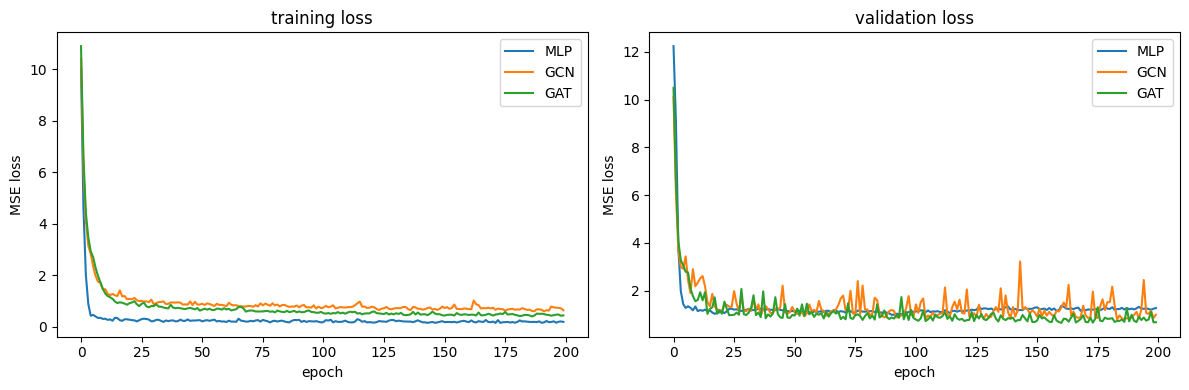

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# train loss
ax1.plot(mlp_history['train_loss'], label='MLP')
ax1.plot(gcn_history['train_loss'], label='GCN')
ax1.plot(gat_history['train_loss'], label='GAT')
ax1.set_xlabel('epoch')
ax1.set_ylabel('MSE loss')
ax1.set_title('training loss')
ax1.legend()

# val loss
ax2.plot(mlp_history['val_loss'], label='MLP')
ax2.plot(gcn_history['val_loss'], label='GCN')
ax2.plot(gat_history['val_loss'], label='GAT')
ax2.set_xlabel('epoch')
ax2.set_ylabel('MSE loss')
ax2.set_title('validation loss')
ax2.legend()

plt.tight_layout()
plt.show()

## predicted vs actual

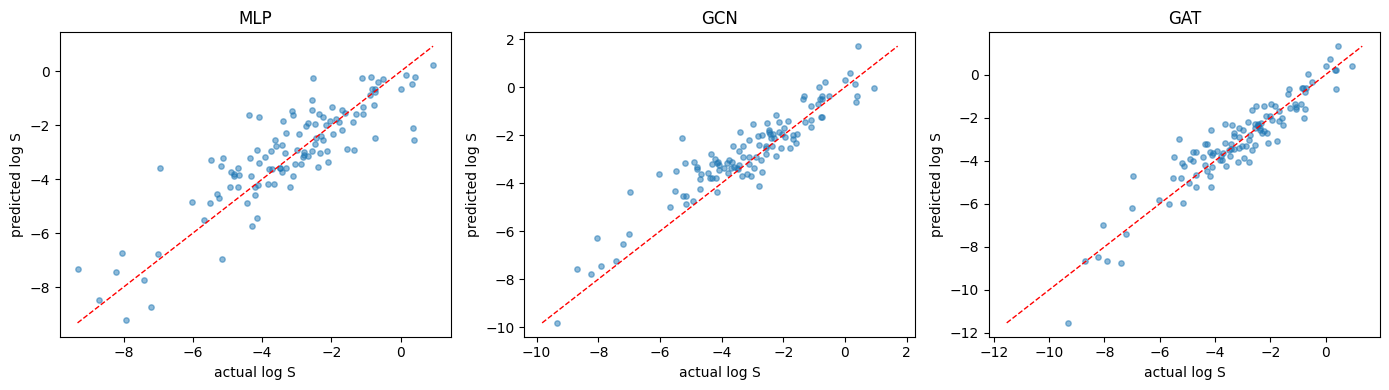

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

all_preds = [
    (mlp_preds.squeeze().detach().numpy(), y_test.squeeze().numpy(), 'MLP'),
    (gcn_preds.detach().numpy(), gcn_targets.detach().numpy(), 'GCN'),
    (gat_preds.detach().numpy(), gat_targets.detach().numpy(), 'GAT'),
]

for ax, (p, t, name) in zip(axes, all_preds):
    ax.scatter(t, p, alpha=0.5, s=15)
    # diagonal line
    lo = min(t.min(), p.min())
    hi = max(t.max(), p.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1)
    ax.set_xlabel('actual log S')
    ax.set_ylabel('predicted log S')
    ax.set_title(name)

plt.tight_layout()
plt.show()